# Deployment-Oriented Operational Evaluation of Unsupervised IDS Models

This notebook reframes the work as a **deployment-oriented IDS evaluation** rather than a generic autoencoder exercise.

## Core evaluation principles

1. **Threshold-sensitive operational analysis**
   - evaluate multiple validation-derived thresholds
   - compare models at several alert budgets / target FPR levels
   - avoid relying on one arbitrary operating point

2. **Ablation evidence**
   - allow comparison between the original dense autoencoder and a more complex hybrid variant
   - test whether added complexity improves recall or merely increases false alarms

3. **Baseline realism**
   - compare dense AE, Isolation Forest, One-Class SVM, and LSTM AE
   - do not assume deep models automatically outperform simpler baselines

## The main claim of the work

Under deployment-oriented evaluation, model choice is governed by the trade-off between attack detection and false alarm burden. In this setting, a simple dense autoencoder provides the strongest overall operating trade-off, Isolation Forest remains highly competitive, LSTM-based complexity does not yield clear operational benefit, and hybrid latent scoring worsens the balance between recall and false positives.


## 1. Imports and Configuration


In [1]:
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers, optimizers
from tensorflow.keras.models import Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix,
)
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import SGDOneClassSVM
from sklearn.kernel_approximation import Nystroem
from sklearn.covariance import EmpiricalCovariance

warnings.filterwarnings("ignore")

SEED = 67
NORMAL_LABEL = 0
ATTACK_LABEL = 1

MAX_ATTACK_SAMPLES_PER_FILE = 100000
THRESHOLD_PERCENTILES = [90, 95, 97, 98, 99, 99.5]
TARGET_FPR_BUDGETS = [0.01, 0.02, 0.05, 0.10]
REFERENCE_PERCENTILE = 95

RUN_LSTM = True
RUN_HYBRID_ABLATION = True   # Set False if you want a faster first pass
LSTM_SEQ_LEN = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
gc.enable()

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")

print("Libraries imported successfully")
print(f"Seed: {SEED}")
print(f"Threshold percentiles: {THRESHOLD_PERCENTILES}")
print(f"Target FPR budgets: {TARGET_FPR_BUDGETS}")
print(f"Run LSTM: {RUN_LSTM}")
print(f"Run hybrid ablation: {RUN_HYBRID_ABLATION}")


Libraries imported successfully
Seed: 67
Threshold percentiles: [90, 95, 97, 98, 99, 99.5]
Target FPR budgets: [0.01, 0.02, 0.05, 0.1]
Run LSTM: True
Run hybrid ablation: True


## 2. Load Baseline Data

The split below is **file-disjoint** and therefore leakage-resistant at the capture-file level.


In [2]:
DATA_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
all_df = pd.read_parquet(os.path.join(DATA_DIR, 'all.parquet'))

METADATA_COLS = ['pcap_file', 'window_id', 'win_start_epoch']
FEAT_COLS = [c for c in all_df.columns if c not in METADATA_COLS]

TRAIN_FILES = (
    [f'Baseline-{str(i).zfill(3)}.pcapng' for i in range(1, 17)] +
    [f'Baseline-30min-{str(i).zfill(3)}.pcapng' for i in range(1, 7)]
)
VAL_FILES  = [f'Baseline-{str(i).zfill(3)}.pcapng' for i in range(17, 21)]
TEST_FILES = ['Baseline-30min-007.pcapng', 'Baseline-60min-001.pcapng', 'Baseline-60min-002.pcapng']

def load_split(file_list, label):
    subset = all_df[all_df['pcap_file'].isin(file_list)].copy()
    subset = subset.sort_values(['pcap_file', 'window_id'])
    df = subset[FEAT_COLS]
    print(f"\n-- {label} --")
    for f in sorted(file_list):
        n = len(all_df[all_df['pcap_file'] == f])
        print(f"  {f:40s} - {n:,} windows")
    print(f"  -> {label} total: {len(df):,} windows")
    del subset
    gc.collect()
    return df

train_df = load_split(TRAIN_FILES, "TRAIN")
val_df   = load_split(VAL_FILES, "VAL")
test_df  = load_split(TEST_FILES, "TEST")

print(f"\nFeature columns: {len(FEAT_COLS)}")
print(FEAT_COLS[:10], "..." if len(FEAT_COLS) > 10 else "")



-- TRAIN --
  Baseline-001.pcapng                      - 11,727 windows
  Baseline-002.pcapng                      - 11,855 windows
  Baseline-003.pcapng                      - 11,873 windows
  Baseline-004.pcapng                      - 11,904 windows
  Baseline-005.pcapng                      - 11,853 windows
  Baseline-006.pcapng                      - 11,876 windows
  Baseline-007.pcapng                      - 11,838 windows
  Baseline-008.pcapng                      - 11,854 windows
  Baseline-009.pcapng                      - 11,851 windows
  Baseline-010.pcapng                      - 11,823 windows
  Baseline-011.pcapng                      - 11,822 windows
  Baseline-012.pcapng                      - 11,830 windows
  Baseline-013.pcapng                      - 11,853 windows
  Baseline-014.pcapng                      - 11,860 windows
  Baseline-015.pcapng                      - 11,850 windows
  Baseline-016.pcapng                      - 11,913 windows
  Baseline-30min-001.pcapng

In [3]:
train_raw = np.nan_to_num(train_df.values, nan=0.0, posinf=0.0, neginf=0.0)
val_raw   = np.nan_to_num(val_df.values,   nan=0.0, posinf=0.0, neginf=0.0)
test_raw  = np.nan_to_num(test_df.values,  nan=0.0, posinf=0.0, neginf=0.0)

print(f"Train raw shape: {train_raw.shape}")
print(f"Val raw shape:   {val_raw.shape}")
print(f"Test raw shape:  {test_raw.shape}")


Train raw shape: (296727, 61)
Val raw shape:   (47447, 61)
Test raw shape:  (89424, 61)


## 3. Scaling Views

We keep two scaling views:

- **MinMaxScaler** for the original dense AE, the classical baselines, and the LSTM AE
- **RobustScaler(5,95)** for the optional optimized hybrid ablation

This makes it possible to compare a simple reference pipeline with a more complex alternative without mixing their preprocessing assumptions.


In [4]:
scaler_minmax = MinMaxScaler()
train_mm = scaler_minmax.fit_transform(train_raw).astype(np.float32)
val_mm   = scaler_minmax.transform(val_raw).astype(np.float32)
test_mm  = scaler_minmax.transform(test_raw).astype(np.float32)

scaler_robust = RobustScaler(quantile_range=(5, 95))
train_rb = scaler_robust.fit_transform(train_raw).astype(np.float32)
val_rb   = scaler_robust.transform(val_raw).astype(np.float32)
test_rb  = scaler_robust.transform(test_raw).astype(np.float32)

print("MinMax view:")
print(f"  Train: {train_mm.shape}")
print(f"  Val:   {val_mm.shape}")
print(f"  Test:  {test_mm.shape}")

print("\nRobust view:")
print(f"  Train: {train_rb.shape}")
print(f"  Val:   {val_rb.shape}")
print(f"  Test:  {test_rb.shape}")


MinMax view:
  Train: (296727, 61)
  Val:   (47447, 61)
  Test:  (89424, 61)

Robust view:
  Train: (296727, 61)
  Val:   (47447, 61)
  Test:  (89424, 61)


## 4. Operational Evaluation Helpers


In [5]:
def reconstruction_mae(model, data, batch_size=2048):
    recon = model.predict(data, batch_size=batch_size, verbose=0)
    err = np.mean(np.abs(recon - data), axis=1)
    return err

def robust_stats(x):
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    mad = max(mad, 1e-6)
    return med, mad

def robust_zscore(x, med, mad):
    return 0.6745 * (x - med) / mad

def sample_contiguous_block(data, max_len):
    if len(data) <= max_len:
        return data
    start = random.randint(0, len(data) - max_len)
    return data[start:start + max_len]

def operational_metrics(normal_scores, dos_scores, fdi_scores, threshold):
    attack_scores = np.concatenate([dos_scores, fdi_scores])
    scores = np.concatenate([normal_scores, attack_scores])
    labels = np.concatenate([
        np.full(len(normal_scores), NORMAL_LABEL, dtype=int),
        np.full(len(attack_scores), ATTACK_LABEL, dtype=int),
    ])
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds, labels=[NORMAL_LABEL, ATTACK_LABEL])
    tn, fp, fn, tp = cm.ravel()

    dos_recall = float(np.mean(dos_scores > threshold)) if len(dos_scores) else np.nan
    fdi_recall = float(np.mean(fdi_scores > threshold)) if len(fdi_scores) else np.nan

    metrics = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(labels, preds),
        "attack_precision": precision_score(labels, preds, pos_label=ATTACK_LABEL, zero_division=0),
        "attack_recall": recall_score(labels, preds, pos_label=ATTACK_LABEL, zero_division=0),
        "attack_f1": f1_score(labels, preds, pos_label=ATTACK_LABEL, zero_division=0),
        "roc_auc": roc_auc_score(labels, scores),
        "pr_auc": average_precision_score(labels, scores),
        "fpr": fp / (tn + fp) if (tn + fp) else np.nan,
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "tp": int(tp),
        "normal_windows": int(tn + fp),
        "attack_windows": int(fn + tp),
        "dos_recall": dos_recall,
        "fdi_recall": fdi_recall,
        "dos_missed": int(np.sum(dos_scores <= threshold)),
        "fdi_missed": int(np.sum(fdi_scores <= threshold)),
        "alerts_per_1k_normals": (fp / (tn + fp) * 1000.0) if (tn + fp) else np.nan,
    }
    return metrics

def evaluate_threshold_grid(model_name, val_scores, test_scores, dos_scores, fdi_scores, percentiles=THRESHOLD_PERCENTILES):
    rows = []
    for pct in percentiles:
        thr = np.percentile(val_scores, pct)
        m = operational_metrics(test_scores, dos_scores, fdi_scores, thr)
        m["model"] = model_name
        m["threshold_percentile"] = pct
        rows.append(m)
    return pd.DataFrame(rows)

def evaluate_fpr_budgets(model_name, val_scores, test_scores, dos_scores, fdi_scores, budgets=TARGET_FPR_BUDGETS):
    rows = []
    for budget in budgets:
        pct = 100.0 * (1.0 - budget)
        thr = np.percentile(val_scores, pct)
        m = operational_metrics(test_scores, dos_scores, fdi_scores, thr)
        m["model"] = model_name
        m["target_fpr_budget"] = budget
        m["threshold_percentile"] = pct
        rows.append(m)
    return pd.DataFrame(rows)

def print_reference_metrics(name, metrics):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Threshold:            {metrics['threshold']:.6f}")
    print(f"Attack precision:     {metrics['attack_precision']*100:.2f}%")
    print(f"Attack recall:        {metrics['attack_recall']*100:.2f}%")
    print(f"Attack F1:            {metrics['attack_f1']*100:.2f}%")
    print(f"ROC-AUC:              {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:               {metrics['pr_auc']:.4f}")
    print(f"False positive rate:  {metrics['fpr']*100:.2f}%")
    print(f"Alerts / 1k normals:  {metrics['alerts_per_1k_normals']:.2f}")
    print(f"DoS recall:           {metrics['dos_recall']*100:.2f}%")
    print(f"FDI recall:           {metrics['fdi_recall']*100:.2f}%")
    print(f"Missed DoS:           {metrics['dos_missed']:,}")
    print(f"Missed FDI:           {metrics['fdi_missed']:,}")

def plot_operating_tradeoff(df, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    x = df["fpr"] * 100
    axes[0].plot(x, df["attack_recall"] * 100, marker="o", linewidth=2)
    axes[0].set_xlabel("Test FPR (%)")
    axes[0].set_ylabel("Attack Recall (%)")
    axes[0].set_title(f"{model_name}: Recall vs FPR")

    axes[1].plot(x, df["attack_precision"] * 100, marker="o", linewidth=2)
    axes[1].set_xlabel("Test FPR (%)")
    axes[1].set_ylabel("Attack Precision (%)")
    axes[1].set_title(f"{model_name}: Precision vs FPR")

    axes[2].plot(x, df["attack_f1"] * 100, marker="o", linewidth=2)
    axes[2].set_xlabel("Test FPR (%)")
    axes[2].set_ylabel("Attack F1 (%)")
    axes[2].set_title(f"{model_name}: F1 vs FPR")

    for ax in axes:
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_score_distribution(normal_scores, dos_scores, fdi_scores, threshold, title, sample_size=30000):
    rng = np.random.default_rng(SEED)
    normal_s = rng.choice(normal_scores, size=min(sample_size, len(normal_scores)), replace=False)
    dos_s = rng.choice(dos_scores, size=min(sample_size, len(dos_scores)), replace=False)
    fdi_s = rng.choice(fdi_scores, size=min(sample_size, len(fdi_scores)), replace=False)
    all_s = np.concatenate([normal_s, dos_s, fdi_s])

    xmin = np.percentile(all_s, 0.5)
    xmax = np.percentile(all_s, 99.0)

    plt.figure(figsize=(14, 5))
    sns.histplot(normal_s, bins=100, color="green", alpha=0.45, label="Normal (test)")
    sns.histplot(dos_s, bins=100, color="red", alpha=0.40, label="DoS")
    sns.histplot(fdi_s, bins=100, color="orange", alpha=0.40, label="FDI")
    plt.axvline(threshold, color="blue", linestyle="--", linewidth=2, label=f"Threshold = {threshold:.4f}")
    plt.xlim(xmin, xmax)
    plt.xlabel("Anomaly score")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

def collect_family_scores(prefix, scaler, score_fn, max_samples_per_file=MAX_ATTACK_SAMPLES_PER_FILE):
    attack_df = all_df[all_df["pcap_file"].str.startswith(prefix)].copy()
    rows = []
    all_scores = []

    for fname, grp in sorted(attack_df.groupby("pcap_file"), key=lambda x: x[0]):
        raw = np.nan_to_num(grp[FEAT_COLS].values, nan=0.0, posinf=0.0, neginf=0.0)
        raw = sample_contiguous_block(raw, max_samples_per_file)
        scaled = scaler.transform(raw).astype(np.float32)
        scores = np.asarray(score_fn(scaled), dtype=float).reshape(-1)

        rows.append({
            "family": prefix,
            "pcap_file": fname,
            "windows_used": int(len(scores)),
            "mean_score": float(np.mean(scores)),
            "std_score": float(np.std(scores)),
        })
        all_scores.extend(scores.tolist())

        del grp, raw, scaled, scores
        gc.collect()

    return np.asarray(all_scores, dtype=float), pd.DataFrame(rows)

def add_reference_detection_columns(df, threshold):
    out = df.copy()
    out["detected@reference"] = np.nan
    out["reference_threshold"] = threshold
    return out


## 5. Original Dense Autoencoder (Reference Model)

This is the original dense reconstruction model, kept as the **reference dense AE**.


In [6]:
n_input = train_mm.shape[1]

class DenseReferenceAE(Model):
    def __init__(self, n_input):
        super().__init__()
        self.encoder = tf.keras.Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(n_input, activation="sigmoid"),
        ])

    def call(self, x):
        return self.decoder(self.encoder(x))

dense_ae = DenseReferenceAE(n_input)
dense_ae.compile(optimizer="adam", loss="mae")

print(f"Reference dense AE architecture: {n_input} -> 32 -> 16 -> 8 -> 16 -> 32 -> {n_input}")


Reference dense AE architecture: 61 -> 32 -> 16 -> 8 -> 16 -> 32 -> 61


In [7]:
early_stop_dense = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

print("Training reference dense AE...")
history_dense = dense_ae.fit(
    train_mm, train_mm,
    epochs=100,
    batch_size=512,
    validation_data=(val_mm, val_mm),
    callbacks=[early_stop_dense],
    verbose=1,
)
print(f"Training complete, stopped at epoch {len(history_dense.history['loss'])}")


Training reference dense AE...
Epoch 1/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0702 - val_loss: 0.0305
Epoch 2/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0312 - val_loss: 0.0297
Epoch 3/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0298 - val_loss: 0.0272
Epoch 4/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0283 - val_loss: 0.0271
Epoch 5/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0280 - val_loss: 0.0265
Epoch 6/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0254 - val_loss: 0.0215
Epoch 7/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0202 - val_loss: 0.0185
Epoch 8/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0185 - val_loss: 0.0165
Epoch 9/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0178 - val_loss: 0.0164
Epoch 10/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0176 - val_loss: 0.0162
Epoch 11/100
580/580 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0175 - val_loss: 0.0161
Epoch 12/1

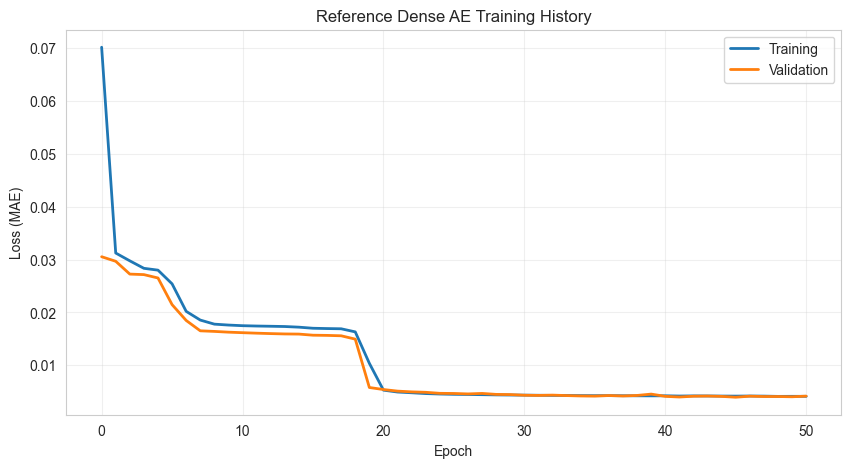

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history_dense.history["loss"], label="Training", linewidth=2)
plt.plot(history_dense.history["val_loss"], label="Validation", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (MAE)")
plt.title("Reference Dense AE Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



Reference Dense AE @ 95th percentile
------------------------------------
Threshold:            0.016957
Attack precision:     91.18%
Attack recall:        76.79%
Attack F1:            83.37%
ROC-AUC:              0.8922
PR-AUC:               0.9119
False positive rate:  5.56%
Alerts / 1k normals:  55.62
DoS recall:           75.84%
FDI recall:           77.61%
Missed DoS:           7,532
Missed FDI:           8,012


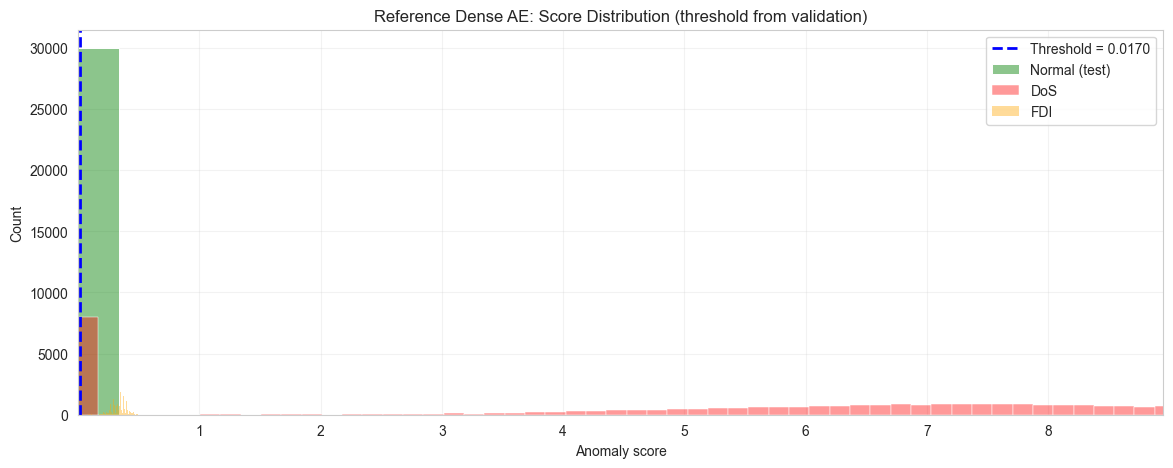

In [9]:
dense_val_scores = reconstruction_mae(dense_ae, val_mm)
dense_test_scores = reconstruction_mae(dense_ae, test_mm)
dense_reference_threshold = np.percentile(dense_val_scores, REFERENCE_PERCENTILE)

dense_dos_scores, dense_dos_files = collect_family_scores(
    "DOS",
    scaler_minmax,
    lambda x: reconstruction_mae(dense_ae, x),
)
dense_fdi_scores, dense_fdi_files = collect_family_scores(
    "FDI",
    scaler_minmax,
    lambda x: reconstruction_mae(dense_ae, x),
)

dense_reference_metrics = operational_metrics(
    dense_test_scores,
    dense_dos_scores,
    dense_fdi_scores,
    dense_reference_threshold,
)

print_reference_metrics("Reference Dense AE @ 95th percentile", dense_reference_metrics)
plot_score_distribution(
    dense_test_scores,
    dense_dos_scores,
    dense_fdi_scores,
    dense_reference_threshold,
    "Reference Dense AE: Score Distribution (threshold from validation)",
)


## 6. Operational Analysis for the Reference Dense AE

The goal here is to show how the **same model** behaves under different alert budgets, rather than making claims from one threshold alone.


Threshold sensitivity (Dense AE)


,threshold_percentile,threshold,attack_precision,attack_recall,attack_f1,fpr,dos_recall,fdi_recall,dos_missed,fdi_missed,roc_auc,pr_auc
0,90.0,0.009806,0.838229,0.786985,0.811799,0.113739,0.778947,0.793987,6892,7373,0.89224,0.911899
1,95.0,0.016957,0.911804,0.767886,0.833679,0.055623,0.758419,0.776132,7532,8012,0.89224,0.911899
2,97.0,0.019732,0.945685,0.763346,0.844789,0.032832,0.753897,0.771578,7673,8175,0.89224,0.911899
3,98.0,0.024101,0.962769,0.759941,0.849415,0.022008,0.750369,0.768281,7783,8293,0.89224,0.911899
4,99.0,0.038562,0.981950,0.757104,0.854992,0.010422,0.746937,0.765962,7890,8376,0.89224,0.911899
5,99.5,0.050763,0.990833,0.755402,0.857247,0.005233,0.745173,0.764313,7945,8435,0.89224,0.911899



Alert-budget view (Dense AE)


,target_fpr_budget,threshold_percentile,threshold,attack_precision,attack_recall,attack_f1,fpr,alerts_per_1k_normals,dos_recall,fdi_recall
0,0.01,99.0,0.038562,0.981950,0.757104,0.854992,0.010422,10.422258,0.746937,0.765962
1,0.02,98.0,0.024101,0.962769,0.759941,0.849415,0.022008,22.007515,0.750369,0.768281
2,0.05,95.0,0.016957,0.911804,0.767886,0.833679,0.055623,55.622652,0.758419,0.776132
3,0.10,90.0,0.009806,0.838229,0.786985,0.811799,0.113739,113.739041,0.778947,0.793987


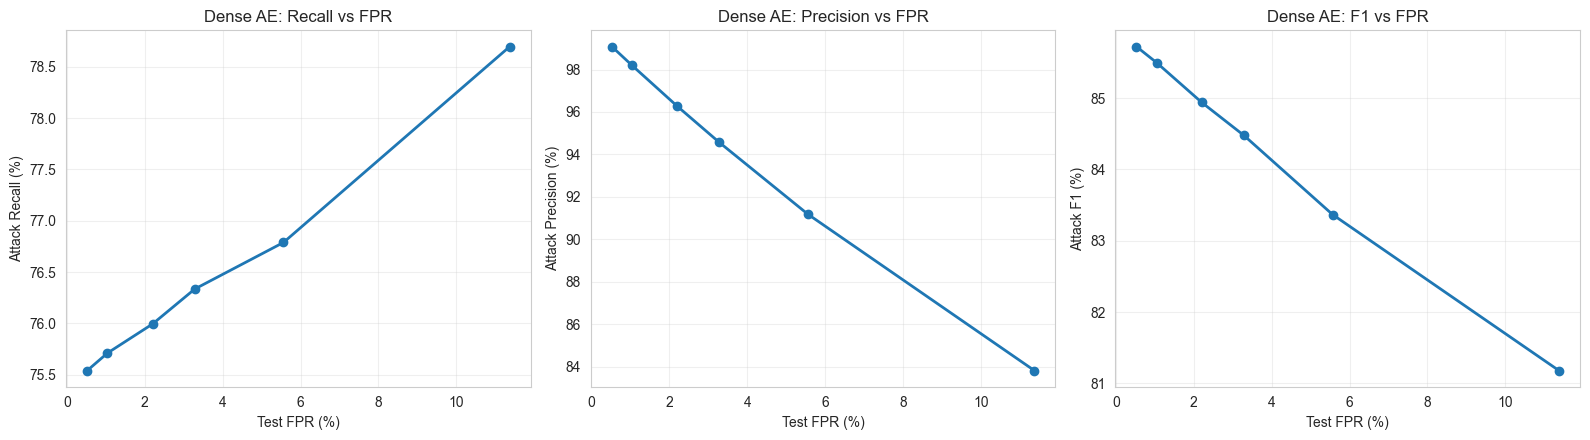

In [10]:
dense_threshold_df = evaluate_threshold_grid(
    "Dense AE",
    dense_val_scores,
    dense_test_scores,
    dense_dos_scores,
    dense_fdi_scores,
)

dense_budget_df = evaluate_fpr_budgets(
    "Dense AE",
    dense_val_scores,
    dense_test_scores,
    dense_dos_scores,
    dense_fdi_scores,
)

print("Threshold sensitivity (Dense AE)")
display(dense_threshold_df[[
    "threshold_percentile", "threshold", "attack_precision", "attack_recall", "attack_f1",
    "fpr", "dos_recall", "fdi_recall", "dos_missed", "fdi_missed", "roc_auc", "pr_auc"
]])

print("\nAlert-budget view (Dense AE)")
display(dense_budget_df[[
    "target_fpr_budget", "threshold_percentile", "threshold", "attack_precision", "attack_recall",
    "attack_f1", "fpr", "alerts_per_1k_normals", "dos_recall", "fdi_recall"
]])

plot_operating_tradeoff(dense_threshold_df, "Dense AE")


## 7. Isolation Forest


In [11]:
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=SEED,
    n_jobs=-1,
)
iso_forest.fit(train_mm)
print("Done.")

iso_val_scores = -iso_forest.decision_function(val_mm)
iso_test_scores = -iso_forest.decision_function(test_mm)
iso_dos_scores, iso_dos_files = collect_family_scores(
    "DOS",
    scaler_minmax,
    lambda x: -iso_forest.decision_function(x),
)
iso_fdi_scores, iso_fdi_files = collect_family_scores(
    "FDI",
    scaler_minmax,
    lambda x: -iso_forest.decision_function(x),
)

iso_reference_threshold = np.percentile(iso_val_scores, REFERENCE_PERCENTILE)
iso_reference_metrics = operational_metrics(
    iso_test_scores, iso_dos_scores, iso_fdi_scores, iso_reference_threshold
)
print_reference_metrics("Isolation Forest @ 95th percentile", iso_reference_metrics)

iso_threshold_df = evaluate_threshold_grid(
    "Isolation Forest",
    iso_val_scores, iso_test_scores, iso_dos_scores, iso_fdi_scores
)
iso_budget_df = evaluate_fpr_budgets(
    "Isolation Forest",
    iso_val_scores, iso_test_scores, iso_dos_scores, iso_fdi_scores
)


Training Isolation Forest...
Done.

Isolation Forest @ 95th percentile
----------------------------------
Threshold:            0.012216
Attack precision:     91.24%
Attack recall:        76.25%
Attack F1:            83.07%
ROC-AUC:              0.8737
PR-AUC:               0.8681
False positive rate:  5.48%
Alerts / 1k normals:  54.80
DoS recall:           75.32%
FDI recall:           77.05%
Missed DoS:           7,694
Missed FDI:           8,214


## 8. One-Class SVM


In [12]:
gamma_scale = 1.0 / (train_mm.shape[1] * train_mm.var())

print(f"Fitting Nystroem RBF approximation (gamma={gamma_scale:.8f})...")
feature_map = Nystroem(gamma=gamma_scale, n_components=100, random_state=SEED)
train_mapped = feature_map.fit_transform(train_mm)

print("Training SGD One-Class SVM...")
ocsvm_sgd = SGDOneClassSVM(nu=0.05, random_state=SEED)
ocsvm_sgd.fit(train_mapped)
print("Done.")

class WrappedOCSVM:
    def decision_function(self, X):
        return ocsvm_sgd.decision_function(feature_map.transform(X))

ocsvm = WrappedOCSVM()

ocsvm_val_scores = -ocsvm.decision_function(val_mm)
ocsvm_test_scores = -ocsvm.decision_function(test_mm)
ocsvm_dos_scores, ocsvm_dos_files = collect_family_scores(
    "DOS",
    scaler_minmax,
    lambda x: -ocsvm.decision_function(x),
)
ocsvm_fdi_scores, ocsvm_fdi_files = collect_family_scores(
    "FDI",
    scaler_minmax,
    lambda x: -ocsvm.decision_function(x),
)

ocsvm_reference_threshold = np.percentile(ocsvm_val_scores, REFERENCE_PERCENTILE)
ocsvm_reference_metrics = operational_metrics(
    ocsvm_test_scores, ocsvm_dos_scores, ocsvm_fdi_scores, ocsvm_reference_threshold
)
print_reference_metrics("One-Class SVM @ 95th percentile", ocsvm_reference_metrics)

ocsvm_threshold_df = evaluate_threshold_grid(
    "One-Class SVM",
    ocsvm_val_scores, ocsvm_test_scores, ocsvm_dos_scores, ocsvm_fdi_scores
)
ocsvm_budget_df = evaluate_fpr_budgets(
    "One-Class SVM",
    ocsvm_val_scores, ocsvm_test_scores, ocsvm_dos_scores, ocsvm_fdi_scores
)


Fitting Nystroem RBF approximation (gamma=0.15944554)...
Training SGD One-Class SVM...
Done.

One-Class SVM @ 95th percentile
-------------------------------
Threshold:            0.007550
Attack precision:     79.29%
Attack recall:        76.11%
Attack F1:            77.67%
ROC-AUC:              0.8353
PR-AUC:               0.8804
False positive rate:  14.89%
Alerts / 1k normals:  148.85
DoS recall:           75.16%
FDI recall:           76.93%
Missed DoS:           7,744
Missed FDI:           8,255


## 9. LSTM Autoencoder

Sequences are built **within each capture file** to preserve temporal integrity and avoid artificial cross-file sequences.


Train sequences: (14824, 20, 61) | used 296,480/296,727 | dropped 247
Val sequences:   (2371, 20, 61) | used 47,420/47,447 | dropped 27
Test sequences:  (4469, 20, 61) | used 89,380/89,424 | dropped 44


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 20, 61)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 32)         │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 20, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 20, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 20, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 61)         │         2,013 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,565 (99.86 KB)

 Trainable params: 25,565 (99.86 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM autoencoder...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.4083 - val_loss: 0.3162
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2183 - val_loss: 0.1403
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1062 - val_loss: 0.0821
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0715 - val_loss: 0.0622
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0577 - val_loss: 0.0526
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0503 - val_loss: 0.0469
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0458 - val_loss: 0.0433
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0429 - val_loss: 0.0408
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0409 - val_loss: 0.0391
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0394 - val_loss: 0.0378
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0383 - val_loss: 0.0368
Epoch 12/100
29/29 ━━━━

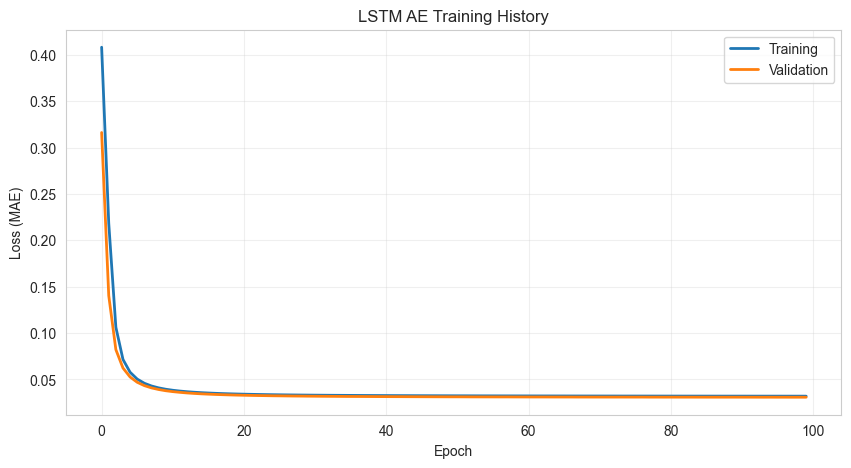


LSTM AE @ 95th percentile
-------------------------
Threshold:            0.134353
Attack precision:     91.89%
Attack recall:        75.54%
Attack F1:            82.92%
ROC-AUC:              0.8827
PR-AUC:               0.9050
False positive rate:  4.98%
Alerts / 1k normals:  49.79
DoS recall:           74.59%
FDI recall:           76.37%
Missed DoS:           7,896
Missed FDI:           8,427


In [13]:
if RUN_LSTM:
    def make_sequences_from_array(arr, seq_len):
        n = (len(arr) // seq_len) * seq_len
        if n == 0:
            return np.empty((0, seq_len, arr.shape[1]), dtype=arr.dtype), 0
        dropped = len(arr) - n
        return arr[:n].reshape(-1, seq_len, arr.shape[1]), dropped

    def make_sequences_from_files(file_list, scaler, seq_len):
        seqs = []
        total_windows = 0
        total_used = 0
        total_dropped = 0

        for fname in file_list:
            grp = all_df[all_df["pcap_file"] == fname].sort_values("window_id")
            raw = np.nan_to_num(grp[FEAT_COLS].values, nan=0.0, posinf=0.0, neginf=0.0)
            scaled = scaler.transform(raw).astype(np.float32)

            total_windows += len(scaled)
            file_seqs, dropped = make_sequences_from_array(scaled, LSTM_SEQ_LEN)
            total_used += len(scaled) - dropped
            total_dropped += dropped

            if len(file_seqs) > 0:
                seqs.append(file_seqs)

            del grp, raw, scaled, file_seqs
            gc.collect()

        if not seqs:
            empty = np.empty((0, LSTM_SEQ_LEN, len(FEAT_COLS)), dtype=np.float32)
            return empty, total_windows, total_used, total_dropped

        return np.concatenate(seqs, axis=0), total_windows, total_used, total_dropped

    train_seq, train_windows, train_used, train_dropped = make_sequences_from_files(TRAIN_FILES, scaler_minmax, LSTM_SEQ_LEN)
    val_seq, val_windows, val_used, val_dropped = make_sequences_from_files(VAL_FILES, scaler_minmax, LSTM_SEQ_LEN)
    test_seq, test_windows, test_used, test_dropped = make_sequences_from_files(TEST_FILES, scaler_minmax, LSTM_SEQ_LEN)

    print(f"Train sequences: {train_seq.shape} | used {train_used:,}/{train_windows:,} | dropped {train_dropped:,}")
    print(f"Val sequences:   {val_seq.shape} | used {val_used:,}/{val_windows:,} | dropped {val_dropped:,}")
    print(f"Test sequences:  {test_seq.shape} | used {test_used:,}/{test_windows:,} | dropped {test_dropped:,}")

    inp = tf.keras.Input(shape=(LSTM_SEQ_LEN, n_input))
    x = layers.LSTM(32, return_sequences=True)(inp)
    enc = layers.LSTM(16)(x)
    x = layers.RepeatVector(LSTM_SEQ_LEN)(enc)
    x = layers.LSTM(16, return_sequences=True)(x)
    x = layers.LSTM(32, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(n_input, activation="sigmoid"))(x)

    lstm_ae = Model(inp, out, name="lstm_autoencoder")
    lstm_ae.compile(optimizer="adam", loss="mae")
    lstm_ae.summary()

    early_stop_lstm = callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    print("Training LSTM autoencoder...")
    history_lstm = lstm_ae.fit(
        train_seq, train_seq,
        epochs=100,
        batch_size=512,
        validation_data=(val_seq, val_seq),
        callbacks=[early_stop_lstm],
        verbose=1,
    )
    print(f"Training complete, stopped at epoch {len(history_lstm.history['loss'])}")

    plt.figure(figsize=(10, 5))
    plt.plot(history_lstm.history["loss"], label="Training", linewidth=2)
    plt.plot(history_lstm.history["val_loss"], label="Validation", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MAE)")
    plt.title("LSTM AE Training History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    lstm_val_recon = lstm_ae.predict(val_seq, verbose=0)
    lstm_val_scores = np.mean(np.abs(lstm_val_recon - val_seq), axis=-1).flatten()

    lstm_test_recon = lstm_ae.predict(test_seq, verbose=0)
    lstm_test_scores = np.mean(np.abs(lstm_test_recon - test_seq), axis=-1).flatten()

    def collect_lstm_family_scores(prefix, scaler, seq_len=LSTM_SEQ_LEN, max_samples_per_file=MAX_ATTACK_SAMPLES_PER_FILE):
        attack_df = all_df[all_df["pcap_file"].str.startswith(prefix)].copy()
        rows = []
        all_scores = []

        for fname, grp in sorted(attack_df.groupby("pcap_file"), key=lambda x: x[0]):
            raw = np.nan_to_num(grp[FEAT_COLS].values, nan=0.0, posinf=0.0, neginf=0.0)
            raw = sample_contiguous_block(raw, max_samples_per_file)
            scaled = scaler.transform(raw).astype(np.float32)
            seqs, dropped = make_sequences_from_array(scaled, seq_len)
            if len(seqs) == 0:
                continue

            recon = lstm_ae.predict(seqs, verbose=0)
            scores = np.mean(np.abs(recon - seqs), axis=-1).flatten()

            rows.append({
                "family": prefix,
                "pcap_file": fname,
                "windows_used": int(len(scores)),
                "dropped_windows": int(dropped),
                "mean_score": float(np.mean(scores)),
                "std_score": float(np.std(scores)),
            })
            all_scores.extend(scores.tolist())

            del grp, raw, scaled, seqs, recon, scores
            gc.collect()

        return np.asarray(all_scores, dtype=float), pd.DataFrame(rows)

    lstm_dos_scores, lstm_dos_files = collect_lstm_family_scores("DOS", scaler_minmax)
    lstm_fdi_scores, lstm_fdi_files = collect_lstm_family_scores("FDI", scaler_minmax)

    lstm_reference_threshold = np.percentile(lstm_val_scores, REFERENCE_PERCENTILE)
    lstm_reference_metrics = operational_metrics(
        lstm_test_scores, lstm_dos_scores, lstm_fdi_scores, lstm_reference_threshold
    )
    print_reference_metrics("LSTM AE @ 95th percentile", lstm_reference_metrics)

    lstm_threshold_df = evaluate_threshold_grid(
        "LSTM AE",
        lstm_val_scores, lstm_test_scores, lstm_dos_scores, lstm_fdi_scores
    )
    lstm_budget_df = evaluate_fpr_budgets(
        "LSTM AE",
        lstm_val_scores, lstm_test_scores, lstm_dos_scores, lstm_fdi_scores
    )

    del lstm_val_recon, lstm_test_recon, train_seq, val_seq, test_seq
    gc.collect()
else:
    print("RUN_LSTM is False. Skipping LSTM section.")


## 10. Optional Hybrid Ablation

This section is framed as an **ablation**, not the default final model.

The purpose is to test a more complex variant:
- RobustScaler(5,95)
- denoising + sparse undercomplete AE
- hybrid score = reconstruction branch + latent Mahalanobis branch

If this raises false positives without materially improving recall, that is a useful **negative operational finding**.


Training hybrid ablation AE...
Epoch 1/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0361 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 2/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0089 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 3/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 4/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0053 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 5/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0045 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 6/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 7/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 9/150
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0029 - val_loss: 0

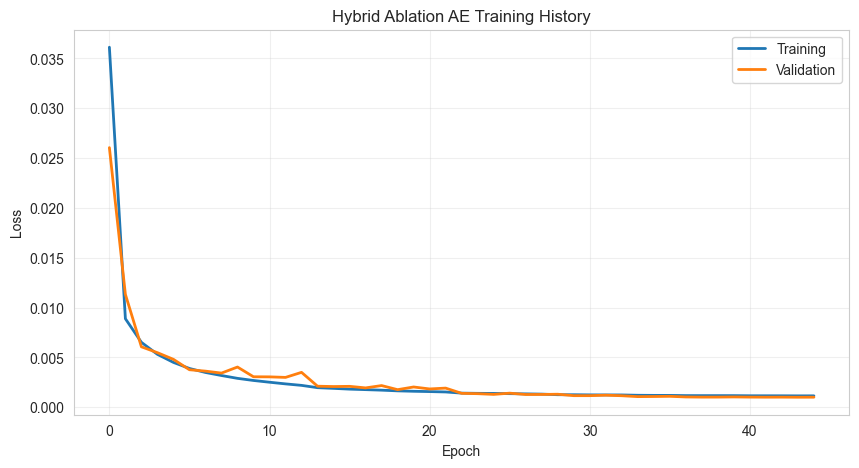


Hybrid Ablation AE @ 95th percentile
------------------------------------
Threshold:            32.188057
Attack precision:     90.46%
Attack recall:        76.12%
Attack F1:            82.67%
ROC-AUC:              0.8789
PR-AUC:               0.9018
False positive rate:  6.01%
Alerts / 1k normals:  60.11
DoS recall:           75.15%
FDI recall:           76.97%
Missed DoS:           7,749
Missed FDI:           8,243


In [14]:
if RUN_HYBRID_ABLATION:
    LATENT_DIM = 8
    NOISE_STD = 0.02
    DROPOUT_RATE = 0.10
    L2_REG = 1e-5
    L1_ACTIVITY = 1e-5

    class HybridAblationAE(Model):
        def __init__(self, n_input, latent_dim=LATENT_DIM):
            super().__init__()
            self.noise = layers.GaussianNoise(NOISE_STD)
            self.encoder = tf.keras.Sequential([
                layers.Dense(64, kernel_regularizer=regularizers.l2(L2_REG)),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Dropout(DROPOUT_RATE),
                layers.Dense(32, kernel_regularizer=regularizers.l2(L2_REG)),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Dense(
                    latent_dim,
                    activation=None,
                    activity_regularizer=regularizers.l1(L1_ACTIVITY),
                    name="latent",
                ),
            ])
            self.decoder = tf.keras.Sequential([
                layers.Dense(32, kernel_regularizer=regularizers.l2(L2_REG)),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Dense(64, kernel_regularizer=regularizers.l2(L2_REG)),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Dense(n_input, activation="linear"),
            ])

        def call(self, x, training=False):
            x_noisy = self.noise(x, training=training)
            z = self.encoder(x_noisy, training=training)
            return self.decoder(z, training=training)

        def encode(self, x, training=False):
            return self.encoder(x, training=training)

    hybrid_ae = HybridAblationAE(n_input)
    hybrid_ae.compile(
        optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
        loss=tf.keras.losses.Huber(delta=1.0),
    )

    early_stop_hybrid = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        min_delta=1e-4,
    )
    reduce_lr_hybrid = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    )

    print("Training hybrid ablation AE...")
    history_hybrid = hybrid_ae.fit(
        train_rb, train_rb,
        epochs=150,
        batch_size=1024,
        validation_data=(val_rb, val_rb),
        callbacks=[early_stop_hybrid, reduce_lr_hybrid],
        verbose=1,
        shuffle=True,
    )
    print(f"Training complete, stopped at epoch {len(history_hybrid.history['loss'])}")

    plt.figure(figsize=(10, 5))
    plt.plot(history_hybrid.history["loss"], label="Training", linewidth=2)
    plt.plot(history_hybrid.history["val_loss"], label="Validation", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Hybrid Ablation AE Training History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    hybrid_train_recon = reconstruction_mae(hybrid_ae, train_rb)
    hybrid_val_recon = reconstruction_mae(hybrid_ae, val_rb)
    hybrid_test_recon = reconstruction_mae(hybrid_ae, test_rb)

    hybrid_train_latent = hybrid_ae.encode(train_rb, training=False).numpy()
    hybrid_val_latent = hybrid_ae.encode(val_rb, training=False).numpy()
    hybrid_test_latent = hybrid_ae.encode(test_rb, training=False).numpy()

    latent_model = EmpiricalCovariance()
    latent_model.fit(hybrid_train_latent)

    hybrid_train_md = latent_model.mahalanobis(hybrid_train_latent)
    hybrid_val_md = latent_model.mahalanobis(hybrid_val_latent)
    hybrid_test_md = latent_model.mahalanobis(hybrid_test_latent)

    recon_med, recon_mad = robust_stats(hybrid_train_recon)
    md_med, md_mad = robust_stats(hybrid_train_md)

    hybrid_val_scores = robust_zscore(hybrid_val_recon, recon_med, recon_mad) + robust_zscore(hybrid_val_md, md_med, md_mad)
    hybrid_test_scores = robust_zscore(hybrid_test_recon, recon_med, recon_mad) + robust_zscore(hybrid_test_md, md_med, md_mad)

    def score_hybrid_batch(data_rb):
        recon_err = reconstruction_mae(hybrid_ae, data_rb)
        latent = hybrid_ae.encode(data_rb, training=False).numpy()
        latent_md = latent_model.mahalanobis(latent)
        scores = robust_zscore(recon_err, recon_med, recon_mad) + robust_zscore(latent_md, md_med, md_mad)
        return scores

    hybrid_dos_scores, hybrid_dos_files = collect_family_scores(
        "DOS",
        scaler_robust,
        score_hybrid_batch,
    )
    hybrid_fdi_scores, hybrid_fdi_files = collect_family_scores(
        "FDI",
        scaler_robust,
        score_hybrid_batch,
    )

    hybrid_reference_threshold = np.percentile(hybrid_val_scores, REFERENCE_PERCENTILE)
    hybrid_reference_metrics = operational_metrics(
        hybrid_test_scores, hybrid_dos_scores, hybrid_fdi_scores, hybrid_reference_threshold
    )
    print_reference_metrics("Hybrid Ablation AE @ 95th percentile", hybrid_reference_metrics)

    hybrid_threshold_df = evaluate_threshold_grid(
        "Hybrid AE",
        hybrid_val_scores, hybrid_test_scores, hybrid_dos_scores, hybrid_fdi_scores
    )
    hybrid_budget_df = evaluate_fpr_budgets(
        "Hybrid AE",
        hybrid_val_scores, hybrid_test_scores, hybrid_dos_scores, hybrid_fdi_scores
    )
else:
    print("RUN_HYBRID_ABLATION is False. Skipping hybrid ablation section.")


## 11. Deployment-Oriented Model Comparison

The tables below are organized around:
- **reference threshold** from the validation 95th percentile
- **threshold sensitivity**
- **alert-budget / FPR-oriented comparison**
- **per-family recall**


In [15]:
model_results = []

def append_reference_row(model_name, ref_metrics):
    row = {
        "Model": model_name,
        "Threshold@ref": ref_metrics["threshold"],
        "Attack Precision (%)": ref_metrics["attack_precision"] * 100,
        "Attack Recall (%)": ref_metrics["attack_recall"] * 100,
        "Attack F1 (%)": ref_metrics["attack_f1"] * 100,
        "Test FPR (%)": ref_metrics["fpr"] * 100,
        "Alerts per 1k normals": ref_metrics["alerts_per_1k_normals"],
        "DoS Recall (%)": ref_metrics["dos_recall"] * 100,
        "FDI Recall (%)": ref_metrics["fdi_recall"] * 100,
        "Missed DoS": ref_metrics["dos_missed"],
        "Missed FDI": ref_metrics["fdi_missed"],
        "ROC-AUC": ref_metrics["roc_auc"],
        "PR-AUC": ref_metrics["pr_auc"],
    }
    model_results.append(row)

append_reference_row("Isolation Forest", iso_reference_metrics)
append_reference_row("One-Class SVM", ocsvm_reference_metrics)
append_reference_row("Dense AE", dense_reference_metrics)

if RUN_LSTM:
    append_reference_row("LSTM AE", lstm_reference_metrics)

if RUN_HYBRID_ABLATION:
    append_reference_row("Hybrid AE", hybrid_reference_metrics)

reference_df = pd.DataFrame(model_results).sort_values(by=["Attack F1 (%)", "Attack Recall (%)"], ascending=False)
print("Reference-threshold comparison (95th percentile on validation)")
display(reference_df)


Reference-threshold comparison (95th percentile on validation)


,Model,Threshold@ref,Attack Precision (%),Attack Recall (%),Attack F1 (%),Test FPR (%),Alerts per 1k normals,DoS Recall (%),FDI Recall (%),Missed DoS,Missed FDI,ROC-AUC,PR-AUC
2,Dense AE,0.016957,91.180382,76.788568,83.367919,5.562265,55.622652,75.841940,77.613233,7532,8012,0.892240,0.911899
0,Isolation Forest,0.012216,91.243589,76.245016,83.072743,5.479513,54.795133,75.322343,77.048814,7694,8214,0.873667,0.868060
3,LSTM AE,0.134353,91.889478,75.542403,82.917924,4.978742,49.787424,74.594595,76.368480,7896,8427,0.882690,0.904972
4,Hybrid AE,32.188057,90.461402,76.119581,82.673111,6.010691,60.106906,75.145936,76.967783,7749,8243,0.878916,0.901780
1,One-Class SVM,0.007550,79.291837,76.109128,77.667891,14.885266,148.852657,75.161973,76.934254,7744,8255,0.835333,0.880388


In [16]:
budget_frames = [iso_budget_df, ocsvm_budget_df, dense_budget_df]
if RUN_LSTM:
    budget_frames.append(lstm_budget_df)
if RUN_HYBRID_ABLATION:
    budget_frames.append(hybrid_budget_df)

all_budget_df = pd.concat(budget_frames, ignore_index=True)
all_budget_df["target_fpr_budget_pct"] = all_budget_df["target_fpr_budget"] * 100

print("Comparison at multiple alert budgets")
display(
    all_budget_df[[
        "model", "target_fpr_budget_pct", "threshold", "attack_precision", "attack_recall",
        "attack_f1", "fpr", "alerts_per_1k_normals", "dos_recall", "fdi_recall", "roc_auc", "pr_auc"
    ]].sort_values(["target_fpr_budget_pct", "attack_f1"], ascending=[True, False])
)


Comparison at multiple alert budgets


,model,target_fpr_budget_pct,threshold,attack_precision,attack_recall,attack_f1,fpr,alerts_per_1k_normals,dos_recall,fdi_recall,roc_auc,pr_auc
8,Dense AE,1.0,0.038562,0.981950,0.757104,0.854992,0.010422,10.422258,0.746937,0.765962,0.892240,0.911899
12,LSTM AE,1.0,0.158398,0.982519,0.753716,0.853041,0.010013,10.013426,0.744080,0.762114,0.882690,0.904972
16,Hybrid AE,1.0,97.890575,0.978142,0.755103,0.852272,0.012636,12.636429,0.745622,0.763363,0.878916,0.901780
4,One-Class SVM,1.0,0.074133,0.972612,0.757254,0.851527,0.015969,15.968867,0.747097,0.766101,0.835333,0.880388
0,Isolation Forest,1.0,0.079665,0.946381,0.246435,0.391043,0.010456,10.455806,0.349413,0.156724,0.873667,0.868060
9,Dense AE,2.0,0.024101,0.962769,0.759941,0.849415,0.022008,22.007515,0.750369,0.768281,0.892240,0.911899
13,LSTM AE,2.0,0.150272,0.967958,0.754105,0.847753,0.018640,18.639517,0.744369,0.762591,0.882690,0.904972
17,Hybrid AE,2.0,51.153640,0.956448,0.757866,0.845655,0.025843,25.843174,0.747643,0.766772,0.878916,0.901780
1,Isolation Forest,2.0,0.053849,0.963381,0.744456,0.839887,0.021191,21.191179,0.747354,0.741932,0.873667,0.868060
5,One-Class SVM,2.0,0.035778,0.892341,0.758598,0.820052,0.068539,68.538647,0.748444,0.767443,0.835333,0.880388


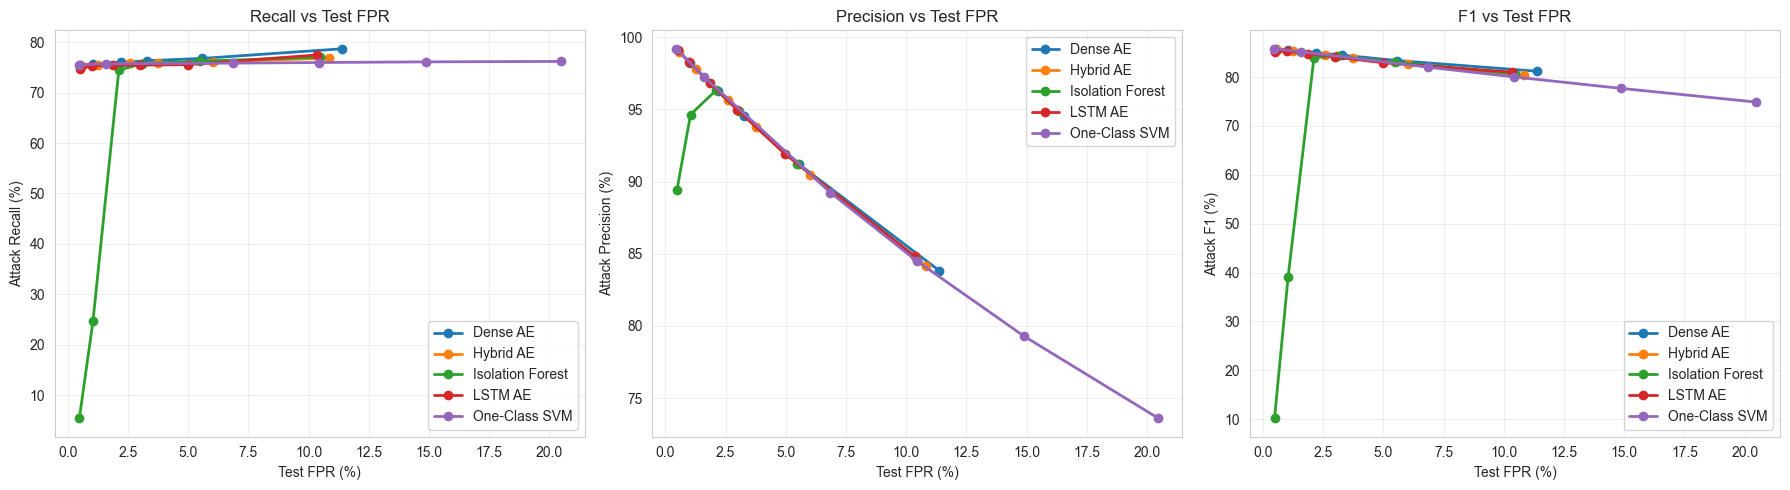

In [17]:
threshold_frames = [iso_threshold_df, ocsvm_threshold_df, dense_threshold_df]
if RUN_LSTM:
    threshold_frames.append(lstm_threshold_df)
if RUN_HYBRID_ABLATION:
    threshold_frames.append(hybrid_threshold_df)

all_threshold_df = pd.concat(threshold_frames, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model_name, grp in all_threshold_df.groupby("model"):
    axes[0].plot(grp["fpr"] * 100, grp["attack_recall"] * 100, marker="o", linewidth=2, label=model_name)
    axes[1].plot(grp["fpr"] * 100, grp["attack_precision"] * 100, marker="o", linewidth=2, label=model_name)
    axes[2].plot(grp["fpr"] * 100, grp["attack_f1"] * 100, marker="o", linewidth=2, label=model_name)

axes[0].set_title("Recall vs Test FPR")
axes[1].set_title("Precision vs Test FPR")
axes[2].set_title("F1 vs Test FPR")

for ax in axes:
    ax.set_xlabel("Test FPR (%)")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Attack Recall (%)")
axes[1].set_ylabel("Attack Precision (%)")
axes[2].set_ylabel("Attack F1 (%)")

plt.tight_layout()
plt.show()


## 12. Ablation-Focused Summary


In [18]:
if RUN_HYBRID_ABLATION:
    ablation_rows = []

    dense_ref = dense_reference_metrics
    hybrid_ref = hybrid_reference_metrics

    ablation_rows.append({
        "Variant": "Dense AE (reference)",
        "Attack Precision (%)": dense_ref["attack_precision"] * 100,
        "Attack Recall (%)": dense_ref["attack_recall"] * 100,
        "Attack F1 (%)": dense_ref["attack_f1"] * 100,
        "Test FPR (%)": dense_ref["fpr"] * 100,
        "DoS Recall (%)": dense_ref["dos_recall"] * 100,
        "FDI Recall (%)": dense_ref["fdi_recall"] * 100,
        "ROC-AUC": dense_ref["roc_auc"],
        "PR-AUC": dense_ref["pr_auc"],
    })
    ablation_rows.append({
        "Variant": "Hybrid AE (ablation)",
        "Attack Precision (%)": hybrid_ref["attack_precision"] * 100,
        "Attack Recall (%)": hybrid_ref["attack_recall"] * 100,
        "Attack F1 (%)": hybrid_ref["attack_f1"] * 100,
        "Test FPR (%)": hybrid_ref["fpr"] * 100,
        "DoS Recall (%)": hybrid_ref["dos_recall"] * 100,
        "FDI Recall (%)": hybrid_ref["fdi_recall"] * 100,
        "ROC-AUC": hybrid_ref["roc_auc"],
        "PR-AUC": hybrid_ref["pr_auc"],
    })

    ablation_df = pd.DataFrame(ablation_rows)
    print("Dense AE vs Hybrid AE ablation at the reference threshold")
    display(ablation_df)
else:
    print("Hybrid ablation was skipped.")


Dense AE vs Hybrid AE ablation at the reference threshold


,Variant,Attack Precision (%),Attack Recall (%),Attack F1 (%),Test FPR (%),DoS Recall (%),FDI Recall (%),ROC-AUC,PR-AUC
0,Dense AE (reference),91.180382,76.788568,83.367919,5.562265,75.841940,77.613233,0.892240,0.911899
1,Hybrid AE (ablation),90.461402,76.119581,82.673111,6.010691,75.145936,76.967783,0.878916,0.901780


In [19]:
print("Recommended outputs to export and use:")
print("1. reference_df                -> reference-threshold comparison")
print("2. all_budget_df               -> alert-budget comparison across models")
print("3. all_threshold_df            -> threshold sensitivity across models")
print("4. dense_threshold_df          -> detailed dense AE operational curve")
print("5. iso_threshold_df            -> Isolation Forest operational curve")
print("6. ocsvm_threshold_df          -> One-Class SVM operational curve")
print("7. lstm_threshold_df           -> LSTM AE operational curve")
print("8. hybrid_threshold_df         -> hybrid ablation operational curve")
print("9. ablation_df                 -> dense AE vs hybrid AE summary")
print("\nUse these exported tables and plots for the BPR results chapter.")


Recommended outputs to export and use:
1. reference_df                -> reference-threshold comparison
2. all_budget_df               -> alert-budget comparison across models
3. all_threshold_df            -> threshold sensitivity across models
4. dense_threshold_df          -> detailed dense AE operational curve
5. iso_threshold_df            -> Isolation Forest operational curve
6. ocsvm_threshold_df          -> One-Class SVM operational curve
7. lstm_threshold_df           -> LSTM AE operational curve
8. hybrid_threshold_df         -> hybrid ablation operational curve
9. ablation_df                 -> dense AE vs hybrid AE summary

Use these exported tables and plots for the BPR results chapter.


1. Reference-threshold comparison


,Model,Threshold@ref,Attack Precision (%),Attack Recall (%),Attack F1 (%),Test FPR (%),Alerts per 1k normals,DoS Recall (%),FDI Recall (%),Missed DoS,Missed FDI,ROC-AUC,PR-AUC
2,Dense AE,0.016957,91.18,76.79,83.37,5.56,55.6,75.84,77.61,7532,8012,0.8922,0.9119
0,Isolation Forest,0.012216,91.24,76.25,83.07,5.48,54.8,75.32,77.05,7694,8214,0.8737,0.8681
3,LSTM AE,0.134353,91.89,75.54,82.92,4.98,49.8,74.59,76.37,7896,8427,0.8827,0.9050
4,Hybrid AE,32.188057,90.46,76.12,82.67,6.01,60.1,75.15,76.97,7749,8243,0.8789,0.9018
1,One-Class SVM,0.007550,79.29,76.11,77.67,14.89,148.9,75.16,76.93,7744,8255,0.8353,0.8804


2. Alert-budget comparison across models


,model,target_fpr_budget_pct,attack_precision,attack_recall,attack_f1,fpr,alerts_per_1k_normals,dos_recall,fdi_recall
0,Isolation Forest,1.000000,0.9464,0.2464,0.3910,0.0105,10.5,0.3494,0.1567
1,Isolation Forest,2.000000,0.9634,0.7445,0.8399,0.0212,21.2,0.7474,0.7419
2,Isolation Forest,5.000000,0.9124,0.7625,0.8307,0.0548,54.8,0.7532,0.7705
3,Isolation Forest,10.000000,0.8465,0.7702,0.8066,0.1046,104.6,0.7610,0.7781
4,One-Class SVM,1.000000,0.9726,0.7573,0.8515,0.0160,16.0,0.7471,0.7661
5,One-Class SVM,2.000000,0.8923,0.7586,0.8201,0.0685,68.5,0.7484,0.7674
6,One-Class SVM,5.000000,0.7929,0.7611,0.7767,0.1489,148.9,0.7516,0.7693
7,One-Class SVM,10.000000,0.7360,0.7620,0.7488,0.2047,204.7,0.7528,0.7700
8,Dense AE,1.000000,0.9819,0.7571,0.8550,0.0104,10.4,0.7469,0.7660
9,Dense AE,2.000000,0.9628,0.7599,0.8494,0.0220,22.0,0.7504,0.7683


3. Threshold sensitivity across all models


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,-0.0211,0.8418,0.8465,0.7702,0.8066,0.8737,0.8681,0.1046,9351,80073,15390,51577,89424,66967,0.7610,0.7781,7450,7940,104.5692,Isolation Forest,90.0000
1,0.0122,0.8669,0.9124,0.7625,0.8307,0.8737,0.8681,0.0548,4900,84524,15908,51059,89424,66967,0.7532,0.7705,7694,8214,54.7951,Isolation Forest,95.0000
2,0.0399,0.8786,0.9487,0.7575,0.8424,0.8737,0.8681,0.0307,2741,86683,16239,50728,89424,66967,0.7489,0.7650,7828,8411,30.6517,Isolation Forest,97.0000
3,0.0538,0.8785,0.9634,0.7445,0.8399,0.8737,0.8681,0.0212,1895,87529,17113,49854,89424,66967,0.7474,0.7419,7877,9236,21.1912,Isolation Forest,98.0000
4,0.0797,0.6713,0.9464,0.2464,0.3910,0.8737,0.8681,0.0105,935,88489,50464,16503,89424,66967,0.3494,0.1567,20284,30180,10.4558,Isolation Forest,99.0000
5,0.1116,0.5922,0.8939,0.0541,0.1021,0.8737,0.8681,0.0048,430,88994,63343,3624,89424,66967,0.0799,0.0317,28687,34656,4.8086,Isolation Forest,99.5000
6,-0.0035,0.7810,0.7360,0.7620,0.7488,0.8353,0.8804,0.2047,18303,71121,15939,51028,89424,66967,0.7528,0.7700,7708,8231,204.6766,One-Class SVM,90.0000
7,0.0076,0.8126,0.7929,0.7611,0.7767,0.8353,0.8804,0.1489,13311,76113,15999,50968,89424,66967,0.7516,0.7693,7744,8255,148.8527,One-Class SVM,95.0000
8,0.0203,0.8375,0.8451,0.7598,0.8002,0.8353,0.8804,0.1043,9329,80095,16086,50881,89424,66967,0.7500,0.7683,7795,8291,104.3232,One-Class SVM,97.0000
9,0.0358,0.8574,0.8923,0.7586,0.8201,0.8353,0.8804,0.0685,6129,83295,16166,50801,89424,66967,0.7484,0.7674,7843,8323,68.5386,One-Class SVM,98.0000


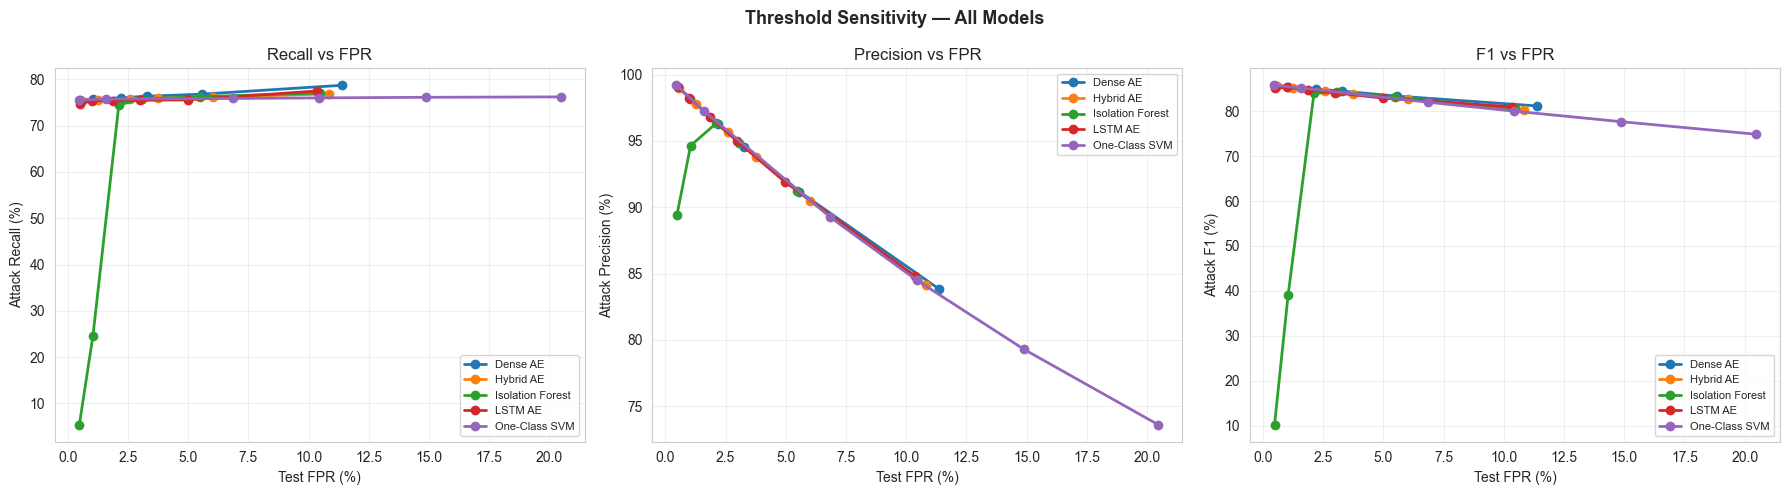

4. Dense AE — operational curve


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,0.0098,0.8438,0.8382,0.7870,0.8118,0.8922,0.9119,0.1137,10171,79253,14265,52702,89424,66967,0.7789,0.7940,6892,7373,113.7390,Dense AE,90.0000
1,0.0170,0.8688,0.9118,0.7679,0.8337,0.8922,0.9119,0.0556,4974,84450,15544,51423,89424,66967,0.7584,0.7761,7532,8012,55.6227,Dense AE,95.0000
2,0.0197,0.8799,0.9457,0.7633,0.8448,0.8922,0.9119,0.0328,2936,86488,15848,51119,89424,66967,0.7539,0.7716,7673,8175,32.8323,Dense AE,97.0000
3,0.0241,0.8846,0.9628,0.7599,0.8494,0.8922,0.9119,0.0220,1968,87456,16076,50891,89424,66967,0.7504,0.7683,7783,8293,22.0075,Dense AE,98.0000
4,0.0386,0.8900,0.9819,0.7571,0.8550,0.8922,0.9119,0.0104,932,88492,16266,50701,89424,66967,0.7469,0.7660,7890,8376,10.4223,Dense AE,99.0000
5,0.0508,0.8923,0.9908,0.7554,0.8572,0.8922,0.9119,0.0052,468,88956,16380,50587,89424,66967,0.7452,0.7643,7945,8435,5.2335,Dense AE,99.5000


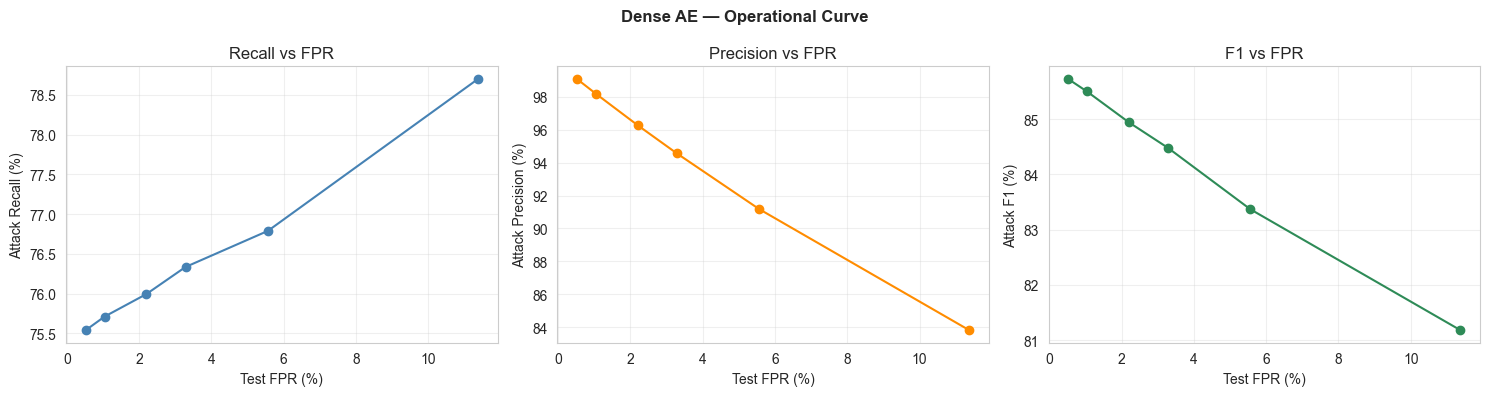

5. LSTM AE — operational curve


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,0.0994,0.8445,0.8482,0.7748,0.8099,0.8827,0.9050,0.1035,9251,80129,15029,51711,89380,66740,0.7657,0.7828,7282,7747,103.5019,LSTM AE,90.0000
1,0.1344,0.8669,0.9189,0.7554,0.8292,0.8827,0.9050,0.0498,4450,84930,16323,50417,89380,66740,0.7459,0.7637,7896,8427,49.7874,LSTM AE,95.0000
2,0.1409,0.8780,0.9497,0.7547,0.8410,0.8827,0.9050,0.0299,2668,86712,16372,50368,89380,66740,0.7449,0.7633,7930,8442,29.8501,LSTM AE,97.0000
3,0.1503,0.8842,0.9680,0.7541,0.8478,0.8827,0.9050,0.0186,1666,87714,16411,50329,89380,66740,0.7444,0.7626,7945,8466,18.6395,LSTM AE,98.0000
4,0.1584,0.8890,0.9825,0.7537,0.8530,0.8827,0.9050,0.0100,895,88485,16437,50303,89380,66740,0.7441,0.7621,7954,8483,10.0134,LSTM AE,99.0000
5,0.1671,0.8887,0.9910,0.7466,0.8516,0.8827,0.9050,0.0051,455,88925,16914,49826,89380,66740,0.7369,0.7550,8176,8738,5.0906,LSTM AE,99.5000


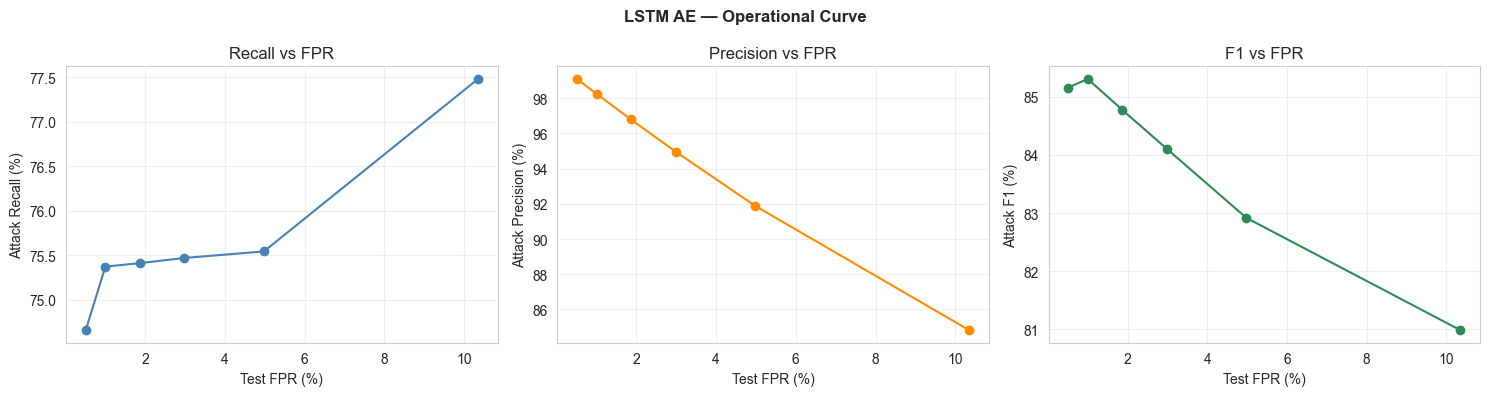

6. Hybrid AE — operational curve


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,21.4183,0.8389,0.8416,0.7683,0.8033,0.8789,0.9018,0.1083,9686,79738,15515,51452,89424,66967,0.7591,0.7764,7512,8003,108.3154,Hybrid AE,90.0000
1,32.1881,0.8634,0.9046,0.7612,0.8267,0.8789,0.9018,0.0601,5375,84049,15992,50975,89424,66967,0.7515,0.7697,7749,8243,60.1069,Hybrid AE,95.0000
2,41.9208,0.8753,0.9380,0.7590,0.8391,0.8789,0.9018,0.0376,3362,86062,16136,50831,89424,66967,0.7492,0.7676,7820,8316,37.5962,Hybrid AE,97.0000
3,51.1536,0.8815,0.9564,0.7579,0.8457,0.8789,0.9018,0.0258,2311,87113,16215,50752,89424,66967,0.7476,0.7668,7868,8347,25.8432,Hybrid AE,98.0000
4,97.8906,0.8879,0.9781,0.7551,0.8523,0.8789,0.9018,0.0126,1130,88294,16400,50567,89424,66967,0.7456,0.7634,7931,8469,12.6364,Hybrid AE,99.0000
5,139.7111,0.8910,0.9899,0.7531,0.8554,0.8789,0.9018,0.0058,517,88907,16532,50435,89424,66967,0.7446,0.7606,7964,8568,5.7814,Hybrid AE,99.5000


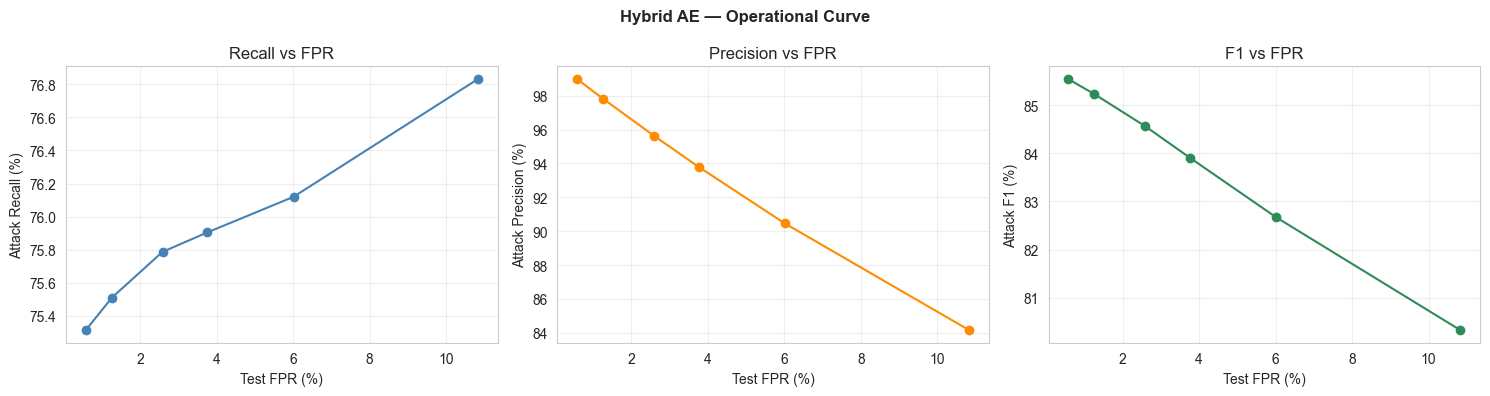

7. Isolation Forest — operational curve


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,-0.0211,0.8418,0.8465,0.7702,0.8066,0.8737,0.8681,0.1046,9351,80073,15390,51577,89424,66967,0.7610,0.7781,7450,7940,104.5692,Isolation Forest,90.0000
1,0.0122,0.8669,0.9124,0.7625,0.8307,0.8737,0.8681,0.0548,4900,84524,15908,51059,89424,66967,0.7532,0.7705,7694,8214,54.7951,Isolation Forest,95.0000
2,0.0399,0.8786,0.9487,0.7575,0.8424,0.8737,0.8681,0.0307,2741,86683,16239,50728,89424,66967,0.7489,0.7650,7828,8411,30.6517,Isolation Forest,97.0000
3,0.0538,0.8785,0.9634,0.7445,0.8399,0.8737,0.8681,0.0212,1895,87529,17113,49854,89424,66967,0.7474,0.7419,7877,9236,21.1912,Isolation Forest,98.0000
4,0.0797,0.6713,0.9464,0.2464,0.3910,0.8737,0.8681,0.0105,935,88489,50464,16503,89424,66967,0.3494,0.1567,20284,30180,10.4558,Isolation Forest,99.0000
5,0.1116,0.5922,0.8939,0.0541,0.1021,0.8737,0.8681,0.0048,430,88994,63343,3624,89424,66967,0.0799,0.0317,28687,34656,4.8086,Isolation Forest,99.5000


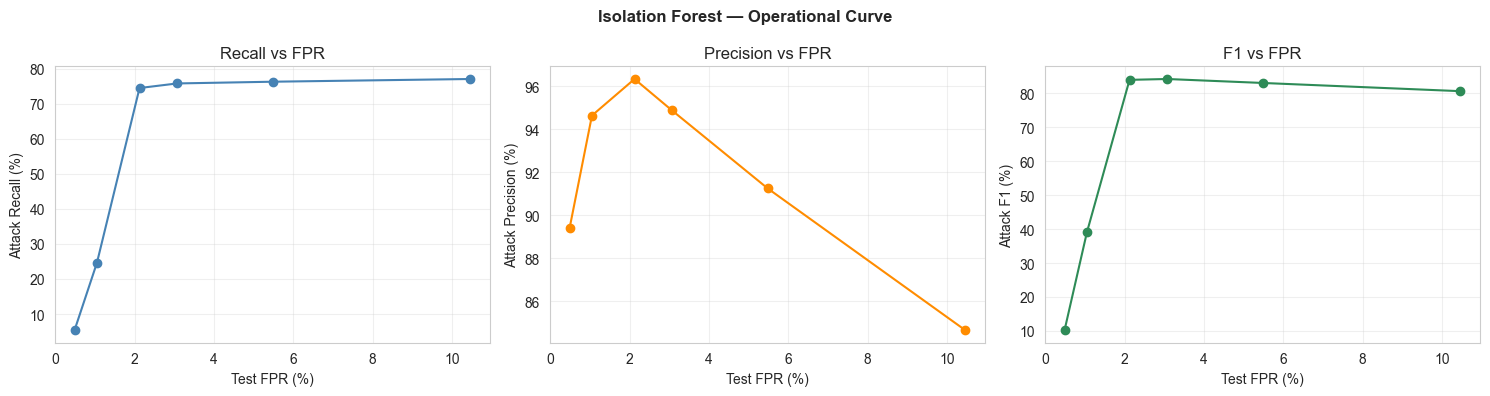

8. One-Class SVM — operational curve


,threshold,accuracy,attack_precision,attack_recall,attack_f1,roc_auc,pr_auc,fpr,fp,tn,fn,tp,normal_windows,attack_windows,dos_recall,fdi_recall,dos_missed,fdi_missed,alerts_per_1k_normals,model,threshold_percentile
0,-0.0035,0.7810,0.7360,0.7620,0.7488,0.8353,0.8804,0.2047,18303,71121,15939,51028,89424,66967,0.7528,0.7700,7708,8231,204.6766,One-Class SVM,90.0000
1,0.0076,0.8126,0.7929,0.7611,0.7767,0.8353,0.8804,0.1489,13311,76113,15999,50968,89424,66967,0.7516,0.7693,7744,8255,148.8527,One-Class SVM,95.0000
2,0.0203,0.8375,0.8451,0.7598,0.8002,0.8353,0.8804,0.1043,9329,80095,16086,50881,89424,66967,0.7500,0.7683,7795,8291,104.3232,One-Class SVM,97.0000
3,0.0358,0.8574,0.8923,0.7586,0.8201,0.8353,0.8804,0.0685,6129,83295,16166,50801,89424,66967,0.7484,0.7674,7843,8323,68.5386,One-Class SVM,98.0000
4,0.0741,0.8869,0.9726,0.7573,0.8515,0.8353,0.8804,0.0160,1428,87996,16256,50711,89424,66967,0.7471,0.7661,7885,8371,15.9689,One-Class SVM,99.0000
5,0.1879,0.8926,0.9919,0.7554,0.8577,0.8353,0.8804,0.0046,412,89012,16377,50590,89424,66967,0.7453,0.7643,7940,8437,4.6073,One-Class SVM,99.5000


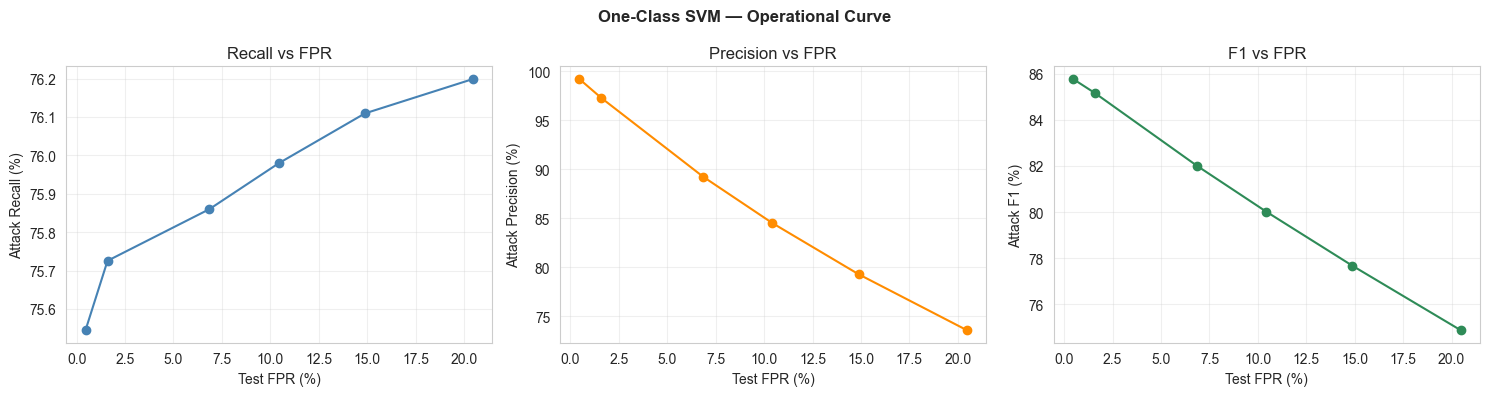

9. Ablation: Dense AE vs Hybrid AE


,Variant,Attack Precision (%),Attack Recall (%),Attack F1 (%),Test FPR (%),DoS Recall (%),FDI Recall (%),ROC-AUC,PR-AUC
0,Dense AE (reference),91.18,76.79,83.37,5.56,75.84,77.61,0.8922,0.9119
1,Hybrid AE (ablation),90.46,76.12,82.67,6.01,75.15,76.97,0.8789,0.9018


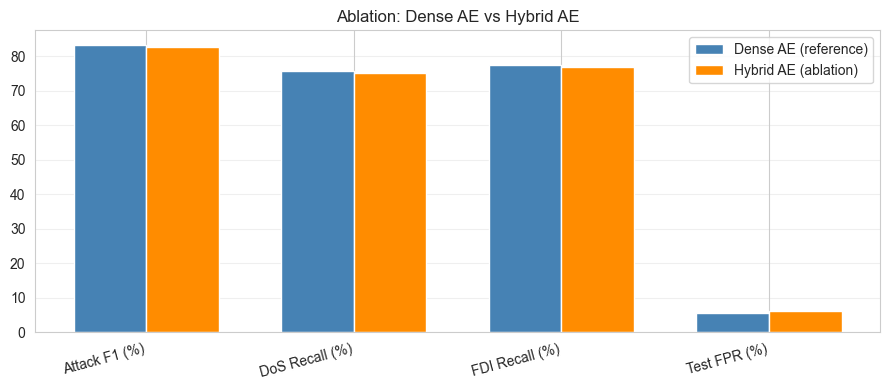

In [20]:
# Visualise outputs above

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# 1. Reference-threshold comparison
print("1. Reference-threshold comparison")
display(reference_df.style.format({
    "Threshold@ref":           "{:.6f}",
    "Attack Precision (%)":    "{:.2f}",
    "Attack Recall (%)":       "{:.2f}",
    "Attack F1 (%)":           "{:.2f}",
    "Test FPR (%)":            "{:.2f}",
    "Alerts per 1k normals":   "{:.1f}",
    "DoS Recall (%)":          "{:.2f}",
    "FDI Recall (%)":          "{:.2f}",
    "ROC-AUC":                 "{:.4f}",
    "PR-AUC":                  "{:.4f}",
}))

# 2. Alert-budget comparison across models
print("2. Alert-budget comparison across models")
display(all_budget_df[[
    "model", "target_fpr_budget_pct", "attack_precision", "attack_recall",
    "attack_f1", "fpr", "alerts_per_1k_normals", "dos_recall", "fdi_recall"
]].style.format({
    "attack_precision":      "{:.4f}",
    "attack_recall":         "{:.4f}",
    "attack_f1":             "{:.4f}",
    "fpr":                   "{:.4f}",
    "alerts_per_1k_normals": "{:.1f}",
    "dos_recall":            "{:.4f}",
    "fdi_recall":            "{:.4f}",
}))

# 3. Threshold sensitivity across all models (plot)
print("3. Threshold sensitivity across all models")
display(all_threshold_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Threshold Sensitivity — All Models", fontsize=13, fontweight="bold")

for model_name, grp in all_threshold_df.groupby("model"):
    fpr_pct = grp["fpr"] * 100
    axes[0].plot(fpr_pct, grp["attack_recall"]    * 100, marker="o", lw=2, label=model_name)
    axes[1].plot(fpr_pct, grp["attack_precision"] * 100, marker="o", lw=2, label=model_name)
    axes[2].plot(fpr_pct, grp["attack_f1"]        * 100, marker="o", lw=2, label=model_name)

titles  = ["Recall vs FPR", "Precision vs FPR", "F1 vs FPR"]
ylabels = ["Attack Recall (%)", "Attack Precision (%)", "Attack F1 (%)"]
for ax, t, y in zip(axes, titles, ylabels):
    ax.set_title(t); ax.set_xlabel("Test FPR (%)"); ax.set_ylabel(y)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 4–8. Individual operational curves (one plot per model)
individual = [
    ("Dense AE",         dense_threshold_df),
    ("LSTM AE",          lstm_threshold_df),
    ("Hybrid AE",        hybrid_threshold_df),
    ("Isolation Forest", iso_threshold_df),
    ("One-Class SVM",    ocsvm_threshold_df),
]

for label_idx, (name, df) in enumerate(individual, start=4):
    print(f"{label_idx}. {name} — operational curve")
    display(df)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{name} — Operational Curve", fontsize=12, fontweight="bold")

    fpr_pct = df["fpr"] * 100
    axes[0].plot(fpr_pct, df["attack_recall"]    * 100, marker="o", color="steelblue")
    axes[1].plot(fpr_pct, df["attack_precision"] * 100, marker="o", color="darkorange")
    axes[2].plot(fpr_pct, df["attack_f1"]        * 100, marker="o", color="seagreen")

    for ax, t, y in zip(axes,
                         ["Recall vs FPR", "Precision vs FPR", "F1 vs FPR"],
                         ["Attack Recall (%)", "Attack Precision (%)", "Attack F1 (%)"]):
        ax.set_title(t); ax.set_xlabel("Test FPR (%)"); ax.set_ylabel(y)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# 9. Ablation summary
print("9. Ablation: Dense AE vs Hybrid AE")

if RUN_HYBRID_ABLATION:
    display(ablation_df.style.format({
        "Attack Precision (%)": "{:.2f}",
        "Attack Recall (%)":    "{:.2f}",
        "Attack F1 (%)":        "{:.2f}",
        "Test FPR (%)":         "{:.2f}",
        "DoS Recall (%)":       "{:.2f}",
        "FDI Recall (%)":       "{:.2f}",
        "ROC-AUC":              "{:.4f}",
        "PR-AUC":               "{:.4f}",
    }))

    metrics = ["Attack F1 (%)", "DoS Recall (%)", "FDI Recall (%)", "Test FPR (%)"]
    x = range(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - width/2 for i in x], ablation_df.iloc[0][metrics], width,
           label=ablation_df.iloc[0]["Variant"], color="steelblue")
    ax.bar([i + width/2 for i in x], ablation_df.iloc[1][metrics], width,
           label=ablation_df.iloc[1]["Variant"], color="darkorange")
    ax.set_xticks(list(x))
    ax.set_xticklabels(metrics, rotation=15, ha="right")
    ax.set_title("Ablation: Dense AE vs Hybrid AE")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Hybrid ablation was skipped.")


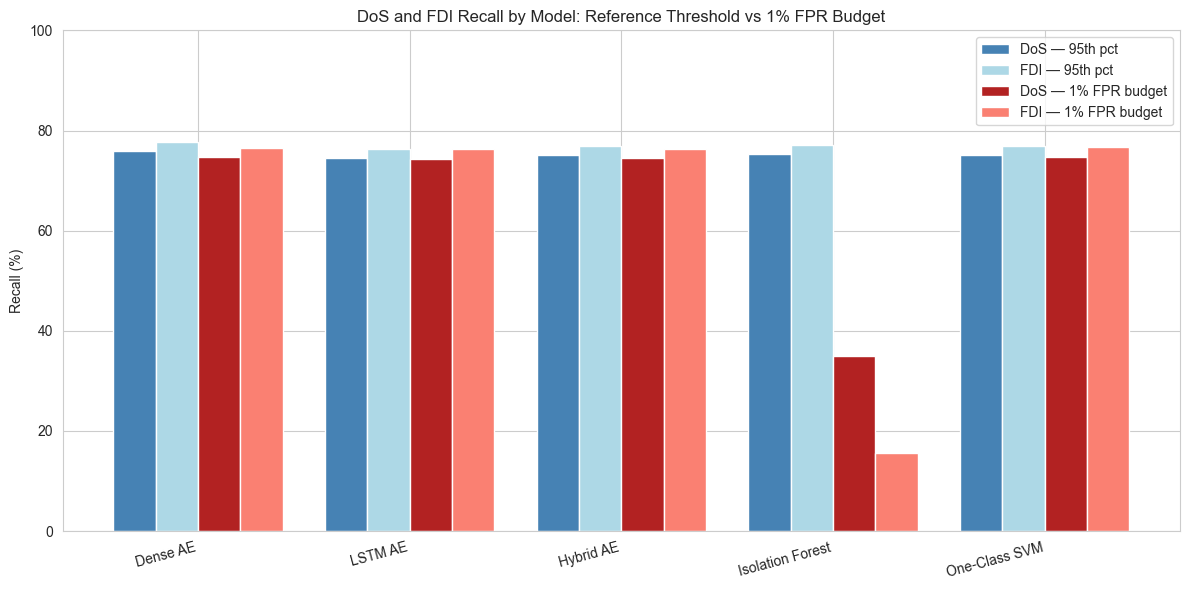

In [21]:
# DoS and FDI recall by Model: Ref Threshold vs 1% FPR Budget

models = ['Dense AE', 'LSTM AE', 'Hybrid AE', 'Isolation Forest', 'One-Class SVM']

# Pull directly from dataframes
ref = all_threshold_df[all_threshold_df['threshold_percentile'] == 95.0].set_index('model')
bud = all_budget_df[all_budget_df['target_fpr_budget_pct'] == 1.0].set_index('model')

dos_ref    = [ref.loc[m, 'dos_recall'] * 100 for m in models]
fdi_ref    = [ref.loc[m, 'fdi_recall'] * 100 for m in models]
dos_budget = [bud.loc[m, 'dos_recall'] * 100 for m in models]
fdi_budget = [bud.loc[m, 'fdi_recall'] * 100 for m in models]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, dos_ref,    width, label='DoS — 95th pct',    color='steelblue')
ax.bar(x - 0.5*width, fdi_ref,    width, label='FDI — 95th pct',    color='lightblue')
ax.bar(x + 0.5*width, dos_budget, width, label='DoS — 1% FPR budget', color='firebrick')
ax.bar(x + 1.5*width, fdi_budget, width, label='FDI — 1% FPR budget', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Recall (%)')
ax.set_title('DoS and FDI Recall by Model: Reference Threshold vs 1% FPR Budget')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()